# Comparación Final — 6 Casos XGBoost
**Completá los resultados de cada notebook y este te dice cuál es el mejor.**

---
### Instrucciones
1. Corré los 6 notebooks anteriores
2. Copiá los valores del bloque de resumen de cada uno
3. Pegálos en la celda de abajo
4. Corré este notebook para ver la comparación completa


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
print("✅ Imports OK")


✅ Imports OK


## 2. Ingresá los resultados de los 6 notebooks

Completá cada valor con lo que te dio el bloque de resumen de cada notebook.
**No cambies los nombres de las variables.**


In [2]:
# ════════════════════════════════════════════════════════════
#  COMPLETÁ ESTOS VALORES con los resultados de tus notebooks
# ════════════════════════════════════════════════════════════

resultados = [
    {
        "nombre":    "Caso 1 Mensual",
        "caso":      "Caso 1",
        "frecuencia":"Mensual",
        "SMAPE":     29.77,   # ← reemplazá con tu valor
        "MAE":       1116.4,
        "RMSE":      1324.0,
        "Bias":      -348.7,
        "R2":        0.510,
        "n":         26,     # períodos evaluados
    },
    {
        "nombre":    "Caso 2 Mensual",
        "caso":      "Caso 2",
        "frecuencia":"Mensual",
        "SMAPE":     29.03,
        "MAE":       1094.3,
        "RMSE":      1279.3,
        "Bias":      -326.6,
        "R2":        0.542,
        "n":         26,
    },
    {
        "nombre":    "Caso 3 Mensual",
        "caso":      "Caso 3",
        "frecuencia":"Mensual",
        "SMAPE":     28.90,
        "MAE":       1064.9,
        "RMSE":      1288.7,
        "Bias":      -334.7,
        "R2":        0.525,
        "n":         26,
    },
    {
        "nombre":    "Caso 1 Semanal",
        "caso":      "Caso 1",
        "frecuencia":"Semanal",
        "SMAPE":     53.90,
        "MAE":       287.7,
        "RMSE":      407.9,
        "Bias":      3.0,
        "R2":        0.843,
        "n":         165,
    },
    {
        "nombre":    "Caso 2 Semanal",
        "caso":      "Caso 2",
        "frecuencia":"Semanal",
        "SMAPE":     43.64,
        "MAE":       359.8,
        "RMSE":      528.9,
        "Bias":      -38.0,
        "R2":        0.756,
        "n":         108,
    },
    {
        "nombre":    "Caso 3 Semanal",
        "caso":      "Caso 3",
        "frecuencia":"Semanal",
        "SMAPE":     47.13,
        "MAE":       291.9,
        "RMSE":      418.9,
        "Bias":      -4.3,
        "R2":        0.828,
        "n":         165,
    },
]

df = pd.DataFrame(resultados)
print("✅ Datos cargados. Continuá con la siguiente celda.")


✅ Datos cargados. Continuá con la siguiente celda.


## 3. Tabla de resultados ordenada por SMAPE

In [3]:
# Ordenar de mejor a peor por SMAPE (menor = mejor)
df_sorted = df.sort_values("SMAPE").reset_index(drop=True)
df_sorted.index += 1  # ranking desde 1

# Formatear para mostrar
display_cols = ["nombre", "SMAPE", "MAE", "RMSE", "Bias", "R2", "n"]
df_display = df_sorted[display_cols].copy()
df_display.columns = ["Combinación", "SMAPE %", "MAE", "RMSE", "Bias", "R²", "N períodos"]

print("=" * 75)
print("  RANKING — menor SMAPE = mejor predicción")
print("=" * 75)
print(df_display.to_string(
    index=True,
    float_format=lambda x: f"{x:.2f}"
))
print("=" * 75)

ganador = df_sorted.iloc[0]
print(f"\n🏆  GANADOR: {ganador['nombre']}")
print(f"    SMAPE: {ganador['SMAPE']:.2f}%  |  MAE: {ganador['MAE']:.1f}  |  Bias: {ganador['Bias']:+.1f}")


  RANKING — menor SMAPE = mejor predicción
      Combinación  SMAPE %     MAE    RMSE    Bias   R²  N períodos
1  Caso 3 Mensual    28.90 1064.90 1288.70 -334.70 0.53          26
2  Caso 2 Mensual    29.03 1094.30 1279.30 -326.60 0.54          26
3  Caso 1 Mensual    29.77 1116.40 1324.00 -348.70 0.51          26
4  Caso 2 Semanal    43.64  359.80  528.90  -38.00 0.76         108
5  Caso 3 Semanal    47.13  291.90  418.90   -4.30 0.83         165
6  Caso 1 Semanal    53.90  287.70  407.90    3.00 0.84         165

🏆  GANADOR: Caso 3 Mensual
    SMAPE: 28.90%  |  MAE: 1064.9  |  Bias: -334.7


## 4. Gráfico de barras — SMAPE por combinación

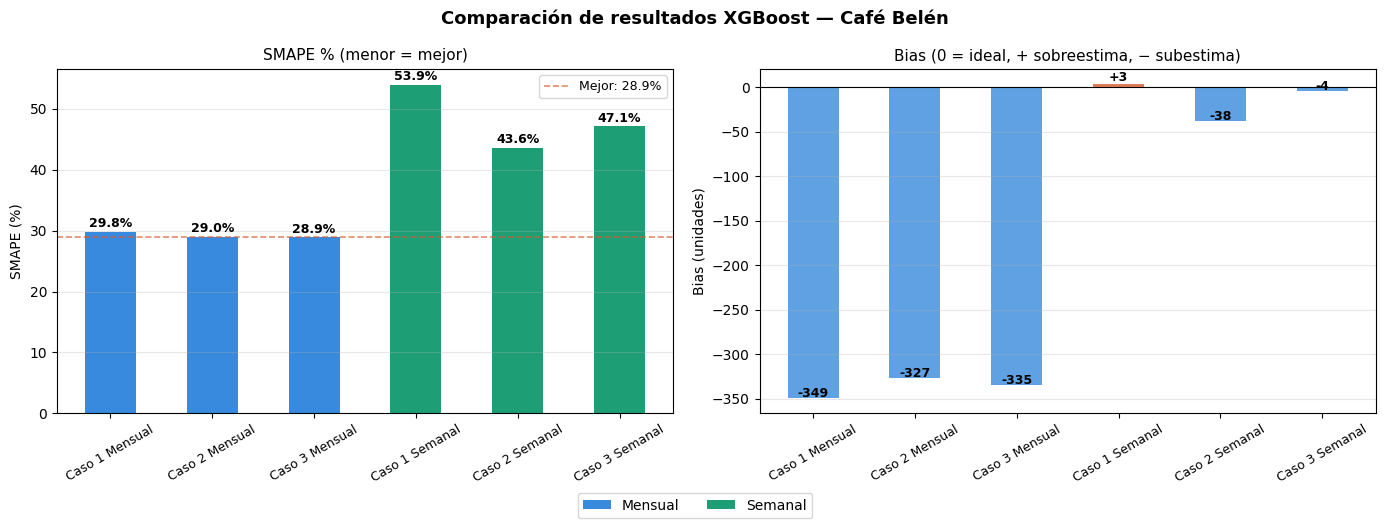

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación de resultados XGBoost — Café Belén", fontsize=13, fontweight="bold")

colores_freq = {"Mensual": "#378ADD", "Semanal": "#1D9E75"}
colores = [colores_freq[f] for f in df["frecuencia"]]

# ── Gráfico 1: SMAPE ──────────────────────────────────────
bars = axes[0].bar(df["nombre"], df["SMAPE"], color=colores, edgecolor="none", width=0.5)
for bar, val in zip(bars, df["SMAPE"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
axes[0].set_title("SMAPE % (menor = mejor)", fontsize=11)
axes[0].set_ylabel("SMAPE (%)")
axes[0].tick_params(axis="x", rotation=30, labelsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Línea del mejor
mejor_smape = df["SMAPE"].min()
axes[0].axhline(mejor_smape, color="#D85A30", linewidth=1.2, linestyle="--", alpha=0.7, label=f"Mejor: {mejor_smape:.1f}%")
axes[0].legend(fontsize=9)

# ── Gráfico 2: Bias ───────────────────────────────────────
colores_bias = ["#D85A30" if b > 0 else "#378ADD" for b in df["Bias"]]
bars2 = axes[1].bar(df["nombre"], df["Bias"], color=colores_bias, edgecolor="none", width=0.5, alpha=0.8)
for bar, val in zip(bars2, df["Bias"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.5 if val >= 0 else -2),
        f"{val:+.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Bias (0 = ideal, + sobreestima, − subestima)", fontsize=11)
axes[1].set_ylabel("Bias (unidades)")
axes[1].tick_params(axis="x", rotation=30, labelsize=9)
axes[1].grid(axis="y", alpha=0.3)

# Leyenda de frecuencia
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor="#378ADD", label="Mensual"), Patch(facecolor="#1D9E75", label="Semanal")]
fig.legend(handles=legend_elems, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()


## 5. Heatmap — SMAPE por caso y frecuencia

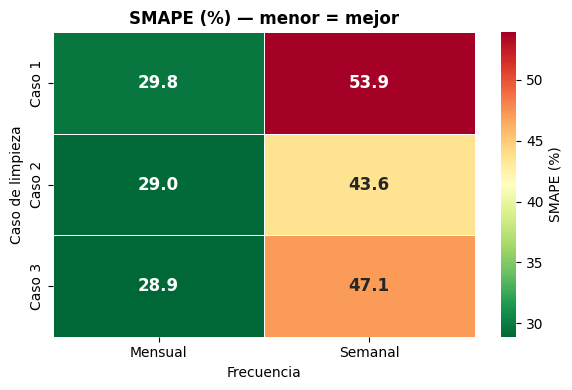

In [5]:
try:
    import seaborn as sns
    pivot = df.pivot(index="caso", columns="frecuencia", values="SMAPE")
    
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
        linewidths=0.5, ax=ax, cbar_kws={"label": "SMAPE (%)"},
        annot_kws={"size": 12, "weight": "bold"}
    )
    ax.set_title("SMAPE (%) — menor = mejor", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Caso de limpieza")
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Instalá seaborn para ver el heatmap: pip install seaborn")
    print("\nTabla equivalente:")
    print(df.pivot(index='caso', columns='frecuencia', values='SMAPE').round(2))


## 6. Comparativa mensual vs semanal — ¿Cuál frecuencia gana?

In [6]:
mensual = df[df["frecuencia"] == "Mensual"]
semanal = df[df["frecuencia"] == "Semanal"]

smape_mensual = mensual["SMAPE"].mean()
smape_semanal = semanal["SMAPE"].mean()

print("=" * 50)
print("  Mensual  — SMAPE promedio: {:.2f}%".format(smape_mensual))
print("  Semanal  — SMAPE promedio: {:.2f}%".format(smape_semanal))
print("=" * 50)

if smape_semanal < smape_mensual:
    diff = smape_mensual - smape_semanal
    print(f"\n✅ Semanal gana por {diff:.2f} puntos de SMAPE")
    print("   Más datos por período ayudaron al modelo a capturar mejor los patrones.")
elif smape_mensual < smape_semanal:
    diff = smape_semanal - smape_mensual
    print(f"\n✅ Mensual gana por {diff:.2f} puntos de SMAPE")
    print("   La agregación mensual reduce el ruido semanal y facilita la predicción.")
else:
    print("\n🔵 Empate — ambas frecuencias dan resultados similares.")


  Mensual  — SMAPE promedio: 29.23%
  Semanal  — SMAPE promedio: 48.22%

✅ Mensual gana por 18.99 puntos de SMAPE
   La agregación mensual reduce el ruido semanal y facilita la predicción.


## 7. Interpretación y recomendación

In [7]:
ganador = df.sort_values("SMAPE").iloc[0]
peor    = df.sort_values("SMAPE").iloc[-1]

print("=" * 60)
print("  RECOMENDACIÓN FINAL")
print("=" * 60)
print(f"\n  Mejor combinación : {ganador['nombre']}")
print(f"  SMAPE             : {ganador['SMAPE']:.2f}%")
print(f"  MAE               : {ganador['MAE']:.1f} unidades por período")
print(f"  Bias              : {ganador['Bias']:+.1f}")
print(f"  R²                : {ganador['R2']:.3f}")
print()

if abs(ganador["Bias"]) < 50:
    print("  ✅ Bias bajo → el modelo no tiene sesgo sistemático importante.")
elif ganador["Bias"] > 0:
    print(f"  ⚠️  Bias positivo ({ganador['Bias']:+.0f}) → el modelo SOBREESTIMA.")
    print("     Considerá ajustar el threshold o usar post-procesamiento.")
else:
    print(f"  ⚠️  Bias negativo ({ganador['Bias']:+.0f}) → el modelo SUBESTIMA.")
    print("     Riesgo de quedar sin stock — considerá un factor de seguridad.")

if ganador["R2"] > 0.7:
    print("  ✅ R² > 0.7 → el modelo explica bien la varianza de la demanda.")
elif ganador["R2"] > 0.4:
    print("  🔵 R² moderado → el modelo captura la tendencia pero hay ruido residual.")
else:
    print("  ⚠️  R² bajo → hay variabilidad que el modelo no logra explicar.")
    print("     Considerá agregar features externas (feriados, promociones, etc.)")

print()
print(f"  Peor combinación  : {peor['nombre']} (SMAPE {peor['SMAPE']:.2f}%)")
print(f"  Diferencia        : {peor['SMAPE'] - ganador['SMAPE']:.2f} puntos de SMAPE")
print("=" * 60)


  RECOMENDACIÓN FINAL

  Mejor combinación : Caso 3 Mensual
  SMAPE             : 28.90%
  MAE               : 1064.9 unidades por período
  Bias              : -334.7
  R²                : 0.525

  ⚠️  Bias negativo (-335) → el modelo SUBESTIMA.
     Riesgo de quedar sin stock — considerá un factor de seguridad.
  🔵 R² moderado → el modelo captura la tendencia pero hay ruido residual.

  Peor combinación  : Caso 1 Semanal (SMAPE 53.90%)
  Diferencia        : 25.00 puntos de SMAPE


## 8. Exportar tabla de resultados

In [8]:
# Guardar resultados como CSV
df_export = df[["nombre", "frecuencia", "caso", "SMAPE", "MAE", "RMSE", "Bias", "R2", "n"]].copy()
df_export = df_export.sort_values("SMAPE").round(3)
df_export.to_csv("resultados_comparacion.csv", index=False)
print("✅ Tabla guardada como resultados_comparacion.csv")
print()
print(df_export.to_string(index=False))


✅ Tabla guardada como resultados_comparacion.csv

        nombre frecuencia   caso  SMAPE    MAE   RMSE   Bias    R2   n
Caso 3 Mensual    Mensual Caso 3  28.90 1064.9 1288.7 -334.7 0.525  26
Caso 2 Mensual    Mensual Caso 2  29.03 1094.3 1279.3 -326.6 0.542  26
Caso 1 Mensual    Mensual Caso 1  29.77 1116.4 1324.0 -348.7 0.510  26
Caso 2 Semanal    Semanal Caso 2  43.64  359.8  528.9  -38.0 0.756 108
Caso 3 Semanal    Semanal Caso 3  47.13  291.9  418.9   -4.3 0.828 165
Caso 1 Semanal    Semanal Caso 1  53.90  287.7  407.9    3.0 0.843 165
